In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ✅ 파일명 수정 (언더바 사용)
data = pd.read_csv('서울시 마포구 휴게음식점 인허가 정보.csv', encoding='EUC-KR')
print("총 데이터 수:", len(data))
data.head()

총 데이터 수: 2865


,개방자치단체코드,관리번호,인허가일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,전화번호,소재지면적,...,공장판매직종업원수,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지
0,3130000,3130000-104-2016-00221,2016-06-29,3,폐업,2,폐업,2026-04-06,NaN,195.60,...,NaN,NaN,NaN,NaN,NaN,N,195.60,NaN,NaN,NaN
1,3130000,3130000-104-2021-00047,2021-03-09,3,폐업,2,폐업,2026-03-31,NaN,120.71,...,NaN,NaN,NaN,NaN,NaN,N,120.71,NaN,NaN,NaN
2,3130000,3130000-104-2022-00212,2022-07-13,1,영업/정상,1,영업,,NaN,25.34,...,NaN,NaN,NaN,NaN,NaN,N,25.34,NaN,NaN,NaN
3,3130000,3130000-104-2025-00108,2025-06-05,3,폐업,2,폐업,2026-04-10,NaN,20.85,...,NaN,NaN,NaN,NaN,NaN,N,20.85,NaN,NaN,NaN
4,3130000,3130000-104-2026-00091,2026-04-10,1,영업/정상,1,영업,,NaN,66.42,...,NaN,NaN,NaN,NaN,NaN,N,66.42,NaN,NaN,NaN


In [2]:
cols = ['사업장명', '상세영업상태명', '인허가일자', '폐업일자', '도로명주소', '좌표정보(X)', '좌표정보(Y)']
data = data[cols].copy()

# 날짜 변환
data['인허가일자'] = pd.to_datetime(data['인허가일자'], errors='coerce')
data['폐업일자']  = pd.to_datetime(data['폐업일자'],  errors='coerce')

# ✅ 프랜차이즈 키워드 수정 (실제 데이터 기준)
franchise_keywords = {
    '스타벅스': '스타벅스',
    '메가커피':  '메가엠지씨',   # ✅ 수정: '메가엠지씨커피' 실제 이름
    '컴포즈':   '컴포즈',
    '빽다방':   '빽다방',
    '투썸':     '투썸플레이스',  # ✅ 수정: '투썸플레이스' 실제 이름
}

def classify(name):
    for brand, keyword in franchise_keywords.items():
        if keyword in str(name):
            return brand
    return '개인카페'

data['브랜드'] = data['사업장명'].apply(classify)

# 브랜드별 수량 확인
print(data['브랜드'].value_counts())

브랜드
개인카페    2752
스타벅스      44
메가커피      28
컴포즈       18
투썸        14
빽다방        9
Name: count, dtype: int64


In [9]:
# 스타벅스
starbucks = data[data['브랜드'] == '스타벅스'].copy()
print(f"마포구 스타벅스 총 {len(starbucks)}개")
print(starbucks[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

마포구 스타벅스 총 44개
                   사업장명 상세영업상태명      인허가일자       폐업일자
83           스타벅스커피서강대점      영업 2014-06-18        NaT
200       스타벅스커피상암사보이시티      영업 2016-05-26        NaT
288          스타벅스상암DMC점      영업 2007-10-01        NaT
293           스타벅스애오개역점      영업 2008-11-10        NaT
325          스타벅스홍대갤러리점      폐업 2009-04-28 2021-02-18
521         스타벅스마포일진빌딩점      영업 2008-09-16        NaT
550       스타벅스 홍대공항철도역점      영업 2017-10-20        NaT
576         스타벅스월드컵경기장점      폐업 2003-05-20 2011-05-31
696              스타벅스공덕      영업 2018-01-09        NaT
853         스타벅스 홍대로데오점      폐업 2007-07-27 2012-09-12
978          스타벅스마포용강동점      영업 2018-10-29        NaT
986        스타벅스커피공덕오거리점      영업 2009-02-16        NaT
1067        스타벅스마포경찰서후문      영업 2018-01-09        NaT
1126      스타벅스커피 서교동사거리      영업 2016-01-21        NaT
1128            스타벅스홍대점      폐업 2002-12-24 2012-12-07
1165           스타벅스커피합정      영업 2016-06-14        NaT
1195          스타벅스 서강대점      폐업 2006-05-04 2011-05-31
1229         

In [22]:
# 메가커피
mega = data[data['브랜드'] == '메가커피'].copy()
print(f"마포구 메가커피 총 {len(mega)}개")
print(mega[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

마포구 메가커피 총 28개
                   사업장명 상세영업상태명      인허가일자       폐업일자
103     메가엠지씨커피 마포시민공원점      영업 2021-02-05        NaT
104       메가엠지씨커피 아현중앙점      영업 2023-04-03        NaT
142      메가엠지씨커피 서울성산초점      영업 2024-07-18        NaT
146      메가엠지씨커피 상수로데오점      영업 2024-09-27        NaT
159       메가엠지씨커피 광흥창역점      영업 2022-04-05        NaT
276       메가엠지씨커피 망원포은점      영업 2025-07-22        NaT
430     메가엠지씨커피 마포아트센터점      영업 2022-05-18        NaT
534      메가엠지씨커피 합정성산중점      영업 2025-05-15        NaT
561      메가엠지씨커피 연남하늘채점      영업 2024-04-30        NaT
609       메가엠지씨커피 망원시장점      영업 2023-03-20        NaT
694    메가엠지씨커피 신촌숲아이파크점      영업 2025-03-07        NaT
761   메가엠지씨커피 마포 오벨리스크점      폐업 2022-10-04 2022-11-03
883      메가엠지씨커피 홍대입구역점      영업 2017-07-24        NaT
1052  메가엠지씨커피 마포한강푸르지오점      영업 2018-06-08        NaT
1071      메가엠지씨커피 마포중앙점      영업 2022-06-08        NaT
1113      메가엠지씨커피 마포구청점      영업 2022-05-23        NaT
1150     메가엠지씨커피 경의선숲길점      영업 2025-11-13        NaT
1262    메가엠지씨

In [10]:
# 컴포즈
compose = data[data['브랜드'] == '컴포즈'].copy()
print(f"마포구 컴포즈 총 {len(compose)}개")
print(compose[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

마포구 컴포즈 총 18개
                             사업장명 상세영업상태명      인허가일자       폐업일자
132                  컴포즈커피 홍대와우산점      영업 2024-06-18        NaT
134                  컴포즈커피 마포경찰서점      영업 2024-07-26        NaT
239    컴포즈커피 공덕역점(COMPOSE COFFEE)      영업 2023-07-18        NaT
264                  컴포즈커피 공덕오거리점      영업 2026-03-25        NaT
273                    컴포즈커피 서강대점      영업 2016-10-21        NaT
280                컴포즈커피(홍대 동교동점)      영업 2021-04-02        NaT
399                컴포즈커피 홈플러스월드컵점      영업 2025-07-07        NaT
437                  컴포즈커피 홍대삼거리점      영업 2022-11-11        NaT
653                   컴포즈커피 망원시장점      영업 2023-03-08        NaT
748                  컴포즈커피(홍대연남점)      영업 2021-11-05        NaT
750                   컴포즈커피 마포신수점      영업 2022-04-29        NaT
830            드라이빙 앤 컴포즈커피 마포구청점      폐업 2023-06-16 2024-04-18
1184                    컴포즈커피 상암점      영업 2016-07-08        NaT
1311  컴포즈커피 마포광흥창점(COMPOSECOFFEE)      영업 2023-04-26        NaT
1556                 컴포즈커피

In [11]:
# 빽다방
baek = data[data['브랜드'] == '빽다방'].copy()
print(f"마포구 빽다방 총 {len(baek)}개")
print(baek[['사업장명', '상세영업상태명', '인허가일자', '폐업일자']].to_string())

마포구 빽다방 총 9개
              사업장명 상세영업상태명      인허가일자       폐업일자
102     빽다방상암KGIT점      영업 2015-07-20        NaT
192       빽다방망원시장점      영업 2016-04-25        NaT
333       빽다방 대흥역점      영업 2023-11-27        NaT
403      빽다방 홍대거리점      영업 2021-03-10        NaT
741      빽다방 상암이안점      영업 2024-05-17        NaT
1613   빽다방 마포시민공원점      영업 2022-10-31        NaT
1674  빽다방홍익대제3기숙사점      영업 2024-08-30        NaT
1924     빽다방 홍대입구점      영업 2015-08-10        NaT
2574      마포연남점빽다방      폐업 2013-12-04 2019-02-22


In [12]:
brands = ['스타벅스', '메가커피', '컴포즈', '빽다방', '투썸', '개인카페']
result = []

for brand in brands:
    df_b = data[data['브랜드'] == brand]
    total  = len(df_b)
    active = (df_b['상세영업상태명'] == '영업').sum()
    closed = (df_b['상세영업상태명'] == '폐업').sum()
    survival_rate = active / total * 100 if total > 0 else 0

    # 평균 영업 기간 (폐업한 가게 기준)
    closed_df = df_b[df_b['폐업일자'].notna() & df_b['인허가일자'].notna()]
    avg_days = (closed_df['폐업일자'] - closed_df['인허가일자']).dt.days.mean()

    result.append({
        '브랜드': brand,
        '전체': total,
        '영업중': active,
        '폐업': closed,
        '생존율(%)': round(survival_rate, 1),
        '평균영업기간(일)': round(avg_days, 0) if pd.notna(avg_days) else None
    })

df_result = pd.DataFrame(result)
print(df_result.to_string(index=False))

 브랜드   전체  영업중   폐업  생존율(%)  평균영업기간(일)
스타벅스   44   32   12    72.7     2227.0
메가커피   28   27    1    96.4       30.0
 컴포즈   18   17    1    94.4      307.0
 빽다방    9    8    1    88.9     1906.0
  투썸   14    8    6    57.1     2004.0
개인카페 2752  756 1996    27.5     1430.0


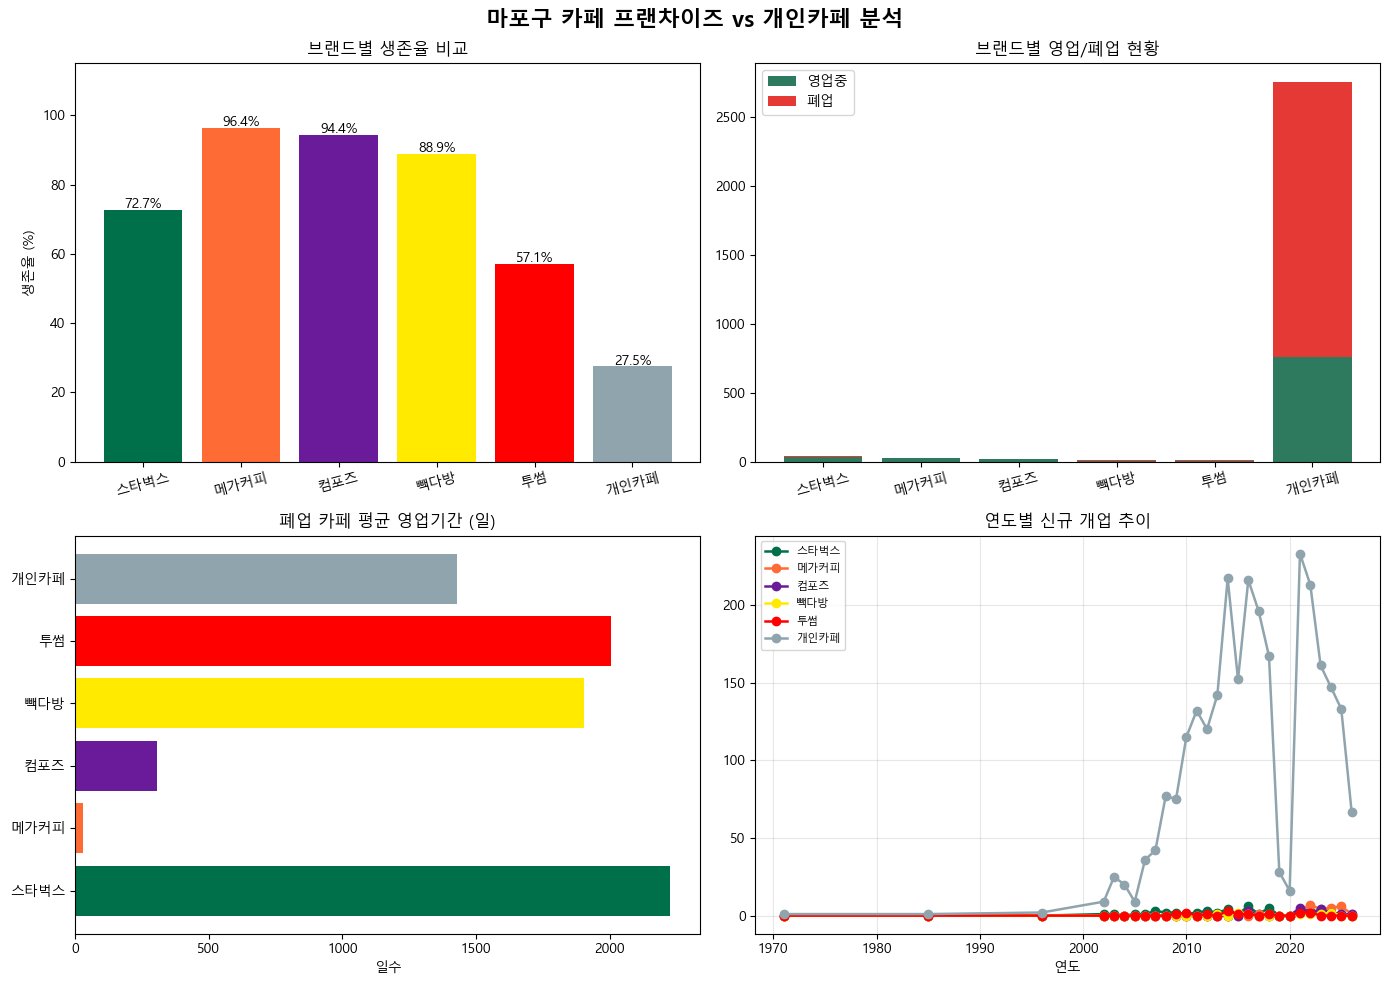

그래프 저장 완료: 마포구_카페_분석.png


In [23]:
colors = {
    '스타벅스': '#00704A',
    '메가커피':  '#FF6B35',
    '컴포즈':   '#6A1B9A',
    '빽다방':   '#FFEA00',
    '투썸':     '#FF0000',
    '개인카페':  '#90A4AE'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('마포구 카페 프랜차이즈 vs 개인카페 분석', fontsize=16, fontweight='bold')

# 그래프 1: 브랜드별 생존율
ax = axes[0][0]
bars = ax.bar(df_result['브랜드'], df_result['생존율(%)'],
              color=[colors[b] for b in df_result['브랜드']])
for bar, val in zip(bars, df_result['생존율(%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10)
ax.set_title('브랜드별 생존율 비교')
ax.set_ylabel('생존율 (%)')
ax.set_ylim(0, 115)
ax.tick_params(axis='x', rotation=15)

# 그래프 2: 영업 vs 폐업 누적 막대
ax = axes[0][1]
x = range(len(df_result))
ax.bar(x, df_result['영업중'], label='영업중', color='#2D7A5E')
ax.bar(x, df_result['폐업'], label='폐업', color='#E53935',
       bottom=df_result['영업중'])
ax.set_xticks(x)
ax.set_xticklabels(df_result['브랜드'], rotation=15)
ax.set_title('브랜드별 영업/폐업 현황')
ax.legend()

# 그래프 3: 평균 영업 기간
ax = axes[1][0]
df_days = df_result.dropna(subset=['평균영업기간(일)'])
ax.barh(df_days['브랜드'], df_days['평균영업기간(일)'],
        color=[colors[b] for b in df_days['브랜드']])
ax.set_title('폐업 카페 평균 영업기간 (일)')
ax.set_xlabel('일수')

# 그래프 4: 연도별 신규 개업 추이
ax = axes[1][1]
data['개업연도'] = data['인허가일자'].dt.year
yearly = data.groupby(['개업연도', '브랜드']).size().unstack(fill_value=0)
for brand in brands:
    if brand in yearly.columns:
        ax.plot(yearly.index, yearly[brand], marker='o',
                color=colors[brand], label=brand, linewidth=1.8)
ax.set_title('연도별 신규 개업 추이')
ax.set_xlabel('연도')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('마포구_카페_분석.png', dpi=150)
plt.show()
print("그래프 저장 완료: 마포구_카페_분석.png")

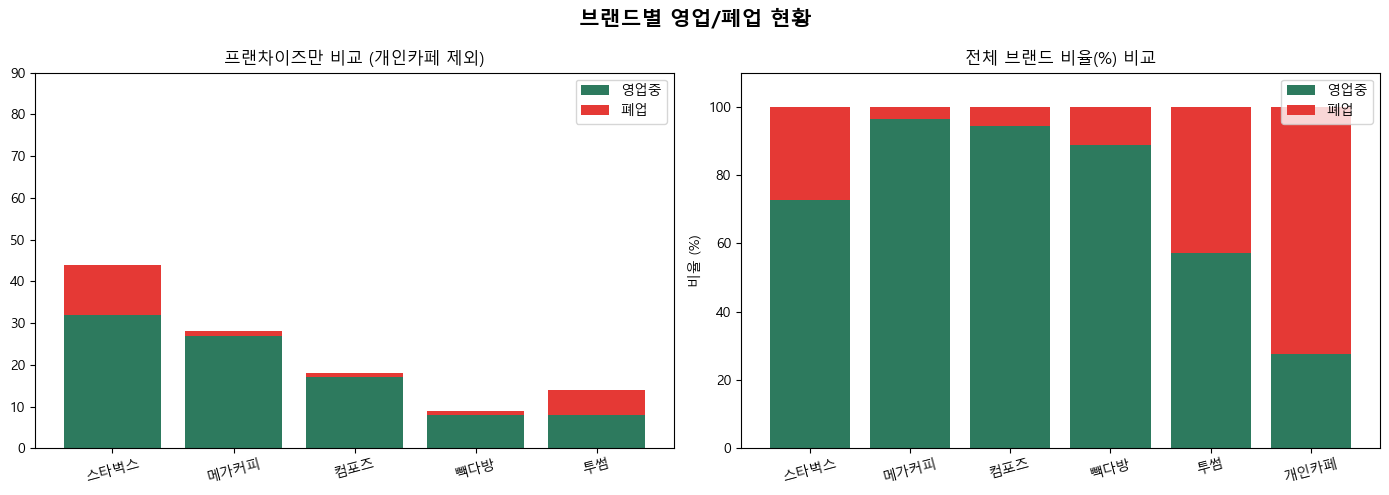

In [15]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

colors = {
    '스타벅스': '#00704A', '메가커피': '#FF6B35',
    '컴포즈': '#6A1B9A', '빽다방': '#FFEA00',
    '투썸': '#FF0000', '개인카페': '#90A4AE'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('브랜드별 영업/폐업 현황', fontsize=15, fontweight='bold')

# ── 그래프 1: 프랜차이즈만 (개인카페 제외) ──
franchise_only = df_result[df_result['브랜드'] != '개인카페']
ax = axes[0]
x = range(len(franchise_only))
ax.bar(x, franchise_only['영업중'], label='영업중', color='#2D7A5E')
ax.bar(x, franchise_only['폐업'], label='폐업', color='#E53935',
       bottom=franchise_only['영업중'].values)
ax.set_xticks(x)
ax.set_xticklabels(franchise_only['브랜드'], rotation=15)
ax.set_ylim(0, 90)  
ax.set_title('프랜차이즈만 비교 (개인카페 제외)')
ax.legend()

# ── 그래프 2: 전체 비율(%) 누적 막대 ──
ax = axes[1]
df_pct = df_result.copy()
df_pct['영업비율'] = df_pct['영업중'] / df_pct['전체'] * 100
df_pct['폐업비율'] = df_pct['폐업']   / df_pct['전체'] * 100

x2 = range(len(df_pct))
ax.bar(x2, df_pct['영업비율'], label='영업중', color='#2D7A5E')
ax.bar(x2, df_pct['폐업비율'], label='폐업', color='#E53935',
       bottom=df_pct['영업비율'].values)
ax.set_xticks(x2)
ax.set_xticklabels(df_pct['브랜드'], rotation=15)
ax.set_ylim(0, 110)
ax.set_ylabel('비율 (%)')
ax.set_title('전체 브랜드 비율(%) 비교')
ax.legend()

plt.tight_layout()
plt.savefig('마포구_영업폐업(개인카페 제외).png', dpi=150)
plt.show()

In [16]:
# ✅ 설치 방법 하나로 통일
import sys
!pip install folium


   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [19]:
!pip install pyproj

In [20]:
import folium
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:5181", "EPSG:4326", always_xy=True)

def tm_to_latlon(x, y):
    lon, lat = transformer.transform(float(x), float(y))
    return lat, lon

# ✅ 공백 문자열까지 걸러내는 필터
map_df = data[
    data['좌표정보(X)'].notna() & data['좌표정보(Y)'].notna() &
    (data['좌표정보(X)'].astype(str).str.strip() != '') &
    (data['좌표정보(Y)'].astype(str).str.strip() != '')
].copy()

lats, lons = [], []
for x, y in zip(map_df['좌표정보(X)'], map_df['좌표정보(Y)']):
    lat, lon = tm_to_latlon(x, y)
    lats.append(lat)
    lons.append(lon)

map_df['위도'] = lats
map_df['경도'] = lons

print(f"지도에 표시할 데이터: {len(map_df)}개")
print(map_df[['사업장명', '위도', '경도']].head(3))

지도에 표시할 데이터: 2813개
                                    사업장명         위도          경도
0                          보헤미안박이추커피 상암점  37.578418  126.889993
1                                    플렘므  37.561466  126.921756
2  삼성에스디에스×폴바셋(SAMSUNG SDS×PAUL BASSETT)  37.580161  126.886399


In [21]:
# 마포구 지도 생성
m = folium.Map(location=[37.4979, 127.0276], zoom_start=13)

color_map = {
    '스타벅스': '#00704A',
    '메가커피':  'orange',
    '컴포즈':   'purple',
    '빽다방':   '#FFEA00',
    '투썸':     '#FF0000',
    '개인카페':  'blue'
}

for _, row in map_df.iterrows():
    try:
        brand  = row['브랜드']
        status = row['상세영업상태명']

        # 폐업 가게는 회색으로 표시
        if status == '폐업':
            pin_color = 'lightgray'
        else:
            pin_color = color_map.get(brand, 'gray')

        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=5,
            color=pin_color,
            fill=True,
            fill_color=pin_color,
            fill_opacity=0.8,
            popup=folium.Popup(f"{row['사업장명']} ({status})", max_width=200)
        ).add_to(m)
    except Exception as e:
        continue

# 범례 추가 (HTML)
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index:1000;
     background: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 13px;">
  <b>브랜드 범례</b><br>
  <span style="color:#00704A">●</span> 스타벅스<br>
  <span style="color:orange">●</span> 메가커피<br>
  <span style="color:purple">●</span> 컴포즈<br>
  <span style="color:#FFEA00">●</span> 빽다방<br>
  <span style="color:#FF0000">●</span> 투썸<br>
  <span style="color:blue">●</span> 개인카페<br>
  <span style="color:lightgray">●</span> 폐업 (전 브랜드)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('마포구_카페_지도.html')
print("지도 저장 완료: 마포구_카페_지도.html")

지도 저장 완료: 마포구_카페_지도.html
